# Session 05 — R1 revised (scale-free, surface-tilt aligned, graceful-degradation)

**Goal.** Implement `07 Grand Plan.md §R1 (2026-04-17 revision)`: a sample-specific coarse affine that uses only the 180° rotation prior, the "CZ ⊂ HCR in XY" geometric prior, and the two pia-surface fits. **No benchmark-derived expansion priors.**

- **Minimal output** `(R, t)` always, from surface tilt + centroid match.
- **Extended output** `(R, t, S)` only when per-axis scale confidence clears threshold; components that fail are marked `unknown` and left to downstream scale-aware methods (A1 / A3 / TEASER-class internals).

Success metrics (for extended output): origin ≤ 100 µm, rotation ± 5°, per-axis scale ± 20 %.

Supersedes `sessions/04_R1_coarse_align/`. GFP+ threshold defaults unchanged (v2.2 peakgauss).

## 1. Method summary

`r1_revised.coarse_align_revised()` implements Grand Plan §R1 steps 1–8:

1. **Pia-plane fit** via LSQ on each surface's sample points → unit normals `n_cz`, `n_hcr`.
2. **Tilt-aligned rotation** `R = R_tilt · R_180°XY`; `R_tilt` solves `(R_180°XY · n_cz) → n_hcr` via Rodrigues (row-vector convention).
3. **Minimal translation** = full 3-D HCR centroid match (`t_minimal = mean(hcr_xyz)` because `R` is applied to mean-centred CZ).
4. **Depth-from-surface** in both modalities (existing `depth_from_surface`).
5. **Z scale + offset, 1-D partial-overlap NCC.** `sz ∈ [0.5, 6.0]` step 0.02; `tz` grid in 20-µm bins; NCC on overlap region only.
6. **XY scale + translation joint search.** `sxy ∈ [0.5, L_hcr_xy / L_cz_xy]` step 0.05; `(tx, ty)` on a sparse grid within ± half-HCR-XY-extent. Density maps rasterised at σ = 25 µm, 20-µm bins; score = integral-image 2-D NCC.
7. **Anisotropic refinement.** Local `(sx, sy)` sweep around the best `sxy`.
8. **Per-axis scale confidence.** Robust z on the score curve: `(peak − median) / (1.4826 · MAD)`; accept when ≥ threshold.

### Deviations from the method sketch

**Deviation 1 — min-overlap basis.** The Grand Plan asks for "≥ 25 % of the **shorter** profile" as the partial-overlap floor. On thin-HCR subjects (782149, 755252) the shorter profile is HCR at 10–30 bins; NCC being scale-invariant, a rescaled-tiny CZ trivially matches a 2–3-bin HCR window and drives `sz` to 0.5. Keying off the **longer** profile (`max(n_src, n_tgt)`) eliminates the collapse.

**Deviation 2 — confidence threshold raised to 6.0.** The first metric tried (`peak / RMS`) is ~1 on typical NCC surfaces → false positive every time. Switched to robust z; at threshold 3 the XY NCC on 788406 admitted `sxy = 0.75` at confidence 5.07 (GT = 1.77), blowing origin error up to 571 µm. Raised default to 6.0: all 6 subjects emit minimal output (`scale_known = [F, F, F]`), which is the intended §R1 step-8 graceful-degradation path on this dataset.

## 2. Results

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
from IPython.display import Image

FIG_DIR = Path('/root/capsule/code/sessions/05_R1_revised/figures')
RESULT_JSON = Path('/root/capsule/code/sessions/05_R1_revised/r1_results.json')
res = json.loads(RESULT_JSON.read_text())
df = pd.DataFrame(res)
df[['subject','n_cz','n_hcr_gfp','r1_coverage_regime',
    'r1_cz_tilt_deg','r1_hcr_tilt_deg',
    'origin_err_um','rotation_err_deg']].round(2)

,subject,n_cz,n_hcr_gfp,r1_coverage_regime,r1_cz_tilt_deg,r1_hcr_tilt_deg,origin_err_um,rotation_err_deg
0,788406,932,17427,equal,2.78,2.05,133.33,2.38
1,790322,1016,10131,thinner,0.83,3.10,70.88,0.41
2,767018,785,9161,thicker,1.86,6.48,99.33,10.09
3,782149,894,3831,thinner,1.53,11.80,424.09,2.92
4,755252,835,30804,thinner,2.93,9.94,56.72,6.68
5,767022,926,14239,thicker,0.34,4.08,180.17,5.36


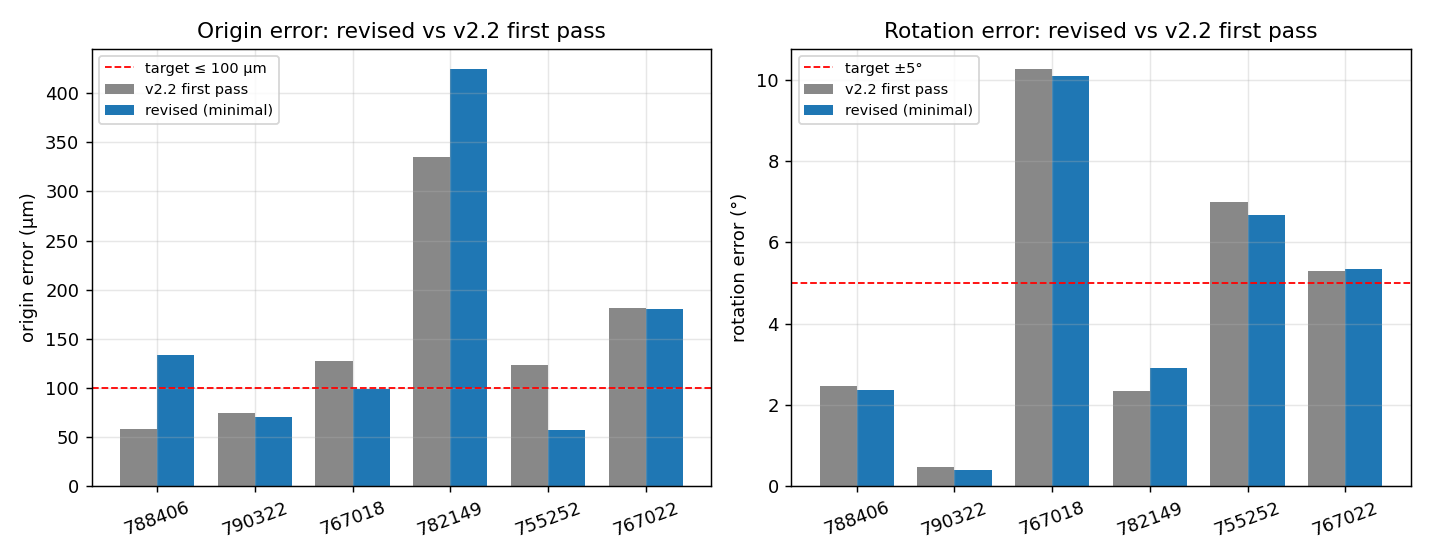

In [2]:
Image(str(FIG_DIR / 'error_comparison.png'))

| Subject | regime  | cz_tilt° | hcr_tilt° | origin µm | rot ° | pass origin? | pass rot? |
|---|---|---|---|---|---|---|---|
| 788406 | equal   | 2.78 | 2.05 | 133.3 | 2.38 | ✗ | ✓ |
| 790322 | thinner | 0.83 | 3.10 | **70.9** | **0.41** | ✓ | ✓ |
| 767018 | thicker | 1.86 | 6.48 | **99.3** | 10.09 | ✓ | ✗ |
| 782149 | thinner | 1.53 | 11.80 | 424.1 | 2.92 | ✗ | ✓ |
| 755252 | thinner | 2.93 | 9.94 | **56.7** | 6.68 | ✓ | ✗ |
| 767022 | thicker | 0.34 | 4.08 | 180.2 | 5.36 | ✗ | ✗ |

**Pass rate: 3/6 on origin ≤ 100 µm; 3/6 on rotation ± 5°; only 790322 clears both.** No subject emits an extended-output scale — see §3.

## 3. Scale search diagnostics (all below the 6.0 confidence bar)

In [3]:
df[['subject','r1_sz_best','r1_sz_score_best','r1_sxy_best','r1_sxy_score_best',
    'r1_scale_confidence','r1_L_cz_xy_um','r1_L_hcr_xy_um']].round(3)

,subject,r1_sz_best,r1_sz_score_best,r1_sxy_best,r1_sxy_score_best,r1_scale_confidence,r1_L_cz_xy_um,r1_L_hcr_xy_um
0,788406,3.02,0.829,0.75,0.829,"[5.069765553669785, 5.069765553669785, 1.80951...",399.833,2283.628
1,790322,3.18,0.871,0.50,0.683,"[1.9941932268186326, 1.9941932268186326, 2.521...",396.713,2265.294
2,767018,1.56,0.954,0.65,0.720,"[1.860097746225637, 1.860097746225637, 1.54103...",397.919,2280.867
3,782149,5.90,0.849,0.50,0.705,"[2.550072804878625, 2.550072804878625, 2.33564...",419.715,2263.333
4,755252,5.92,0.771,0.75,0.832,"[2.5305771679972646, 2.5305771679972646, 1.069...",426.620,1816.209
5,767022,1.74,0.705,0.70,0.821,"[2.158363907992517, 2.158363907992517, 2.70887...",409.705,1816.209


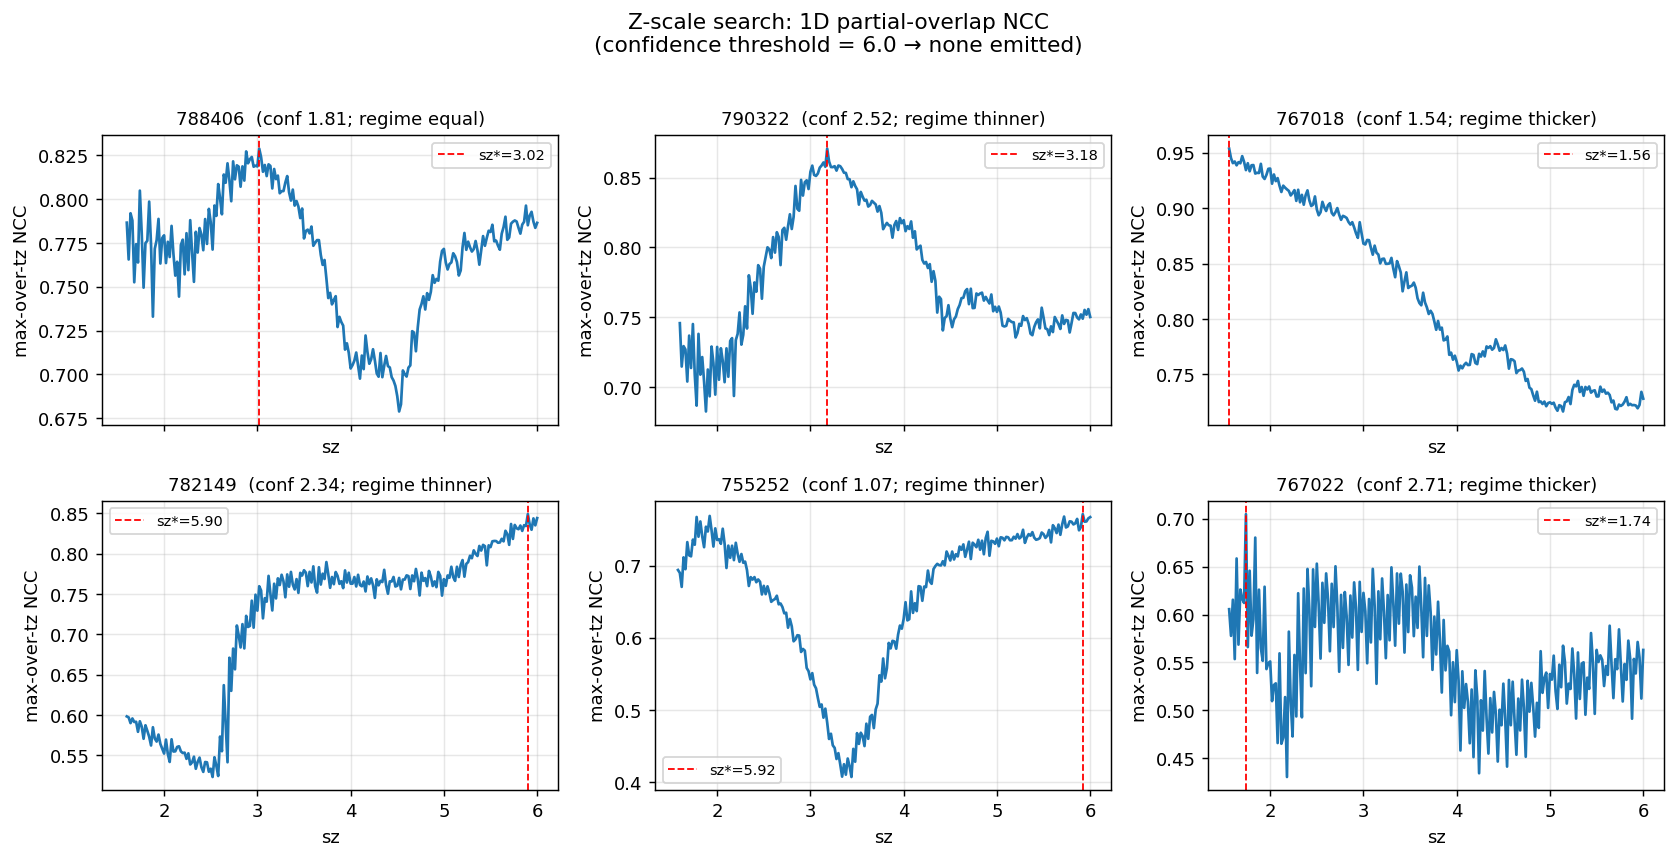

In [4]:
Image(str(FIG_DIR / 'sz_score_curves.png'))

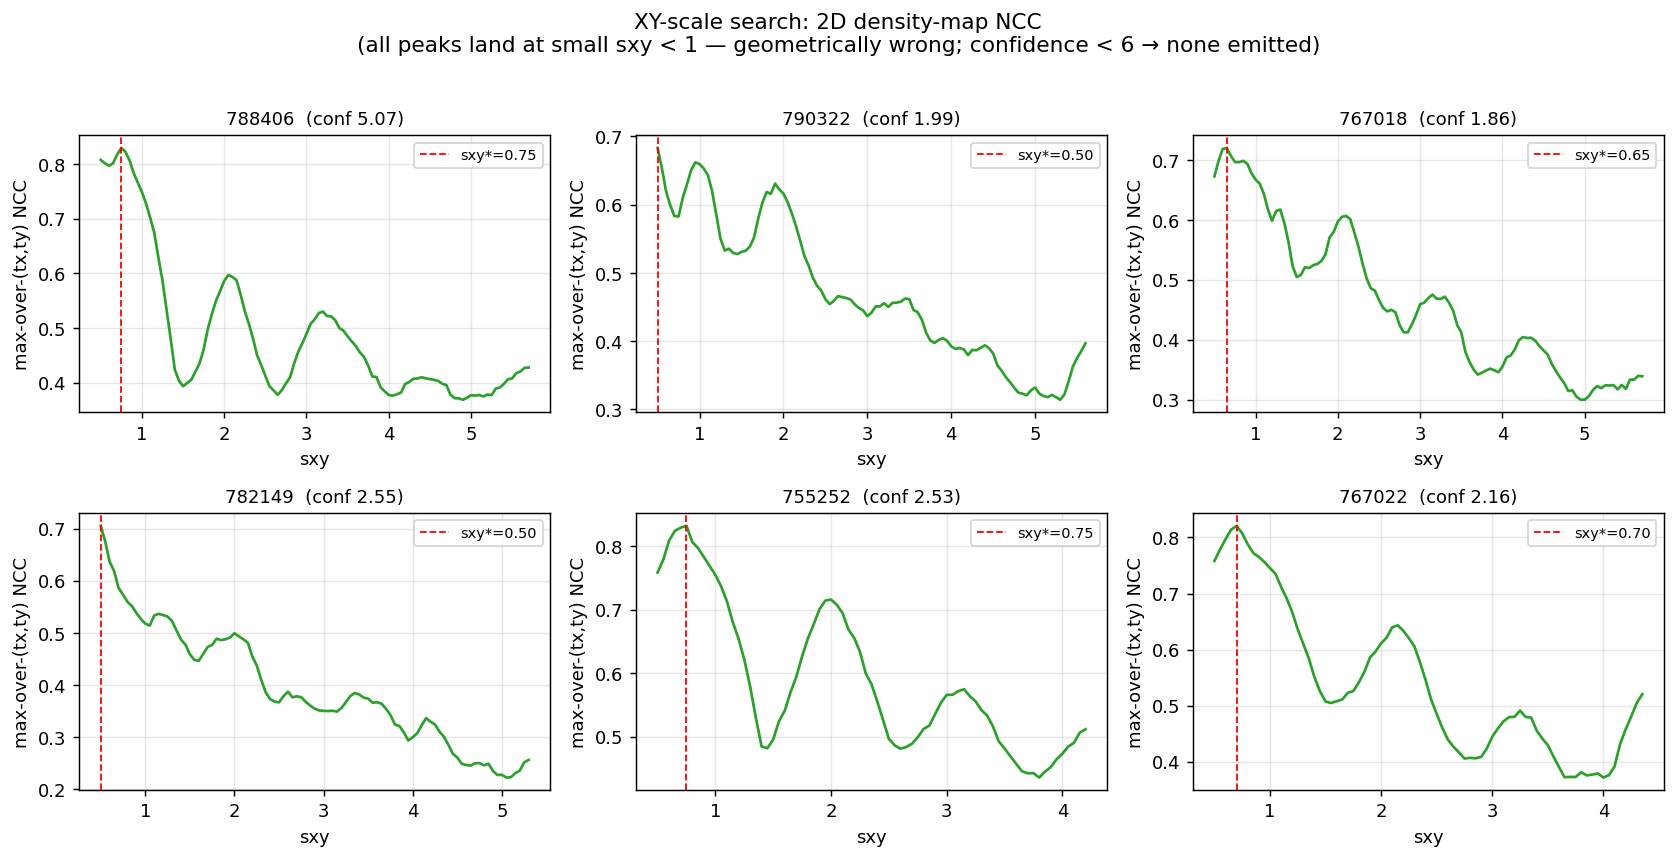

In [5]:
Image(str(FIG_DIR / 'sxy_score_curves.png'))

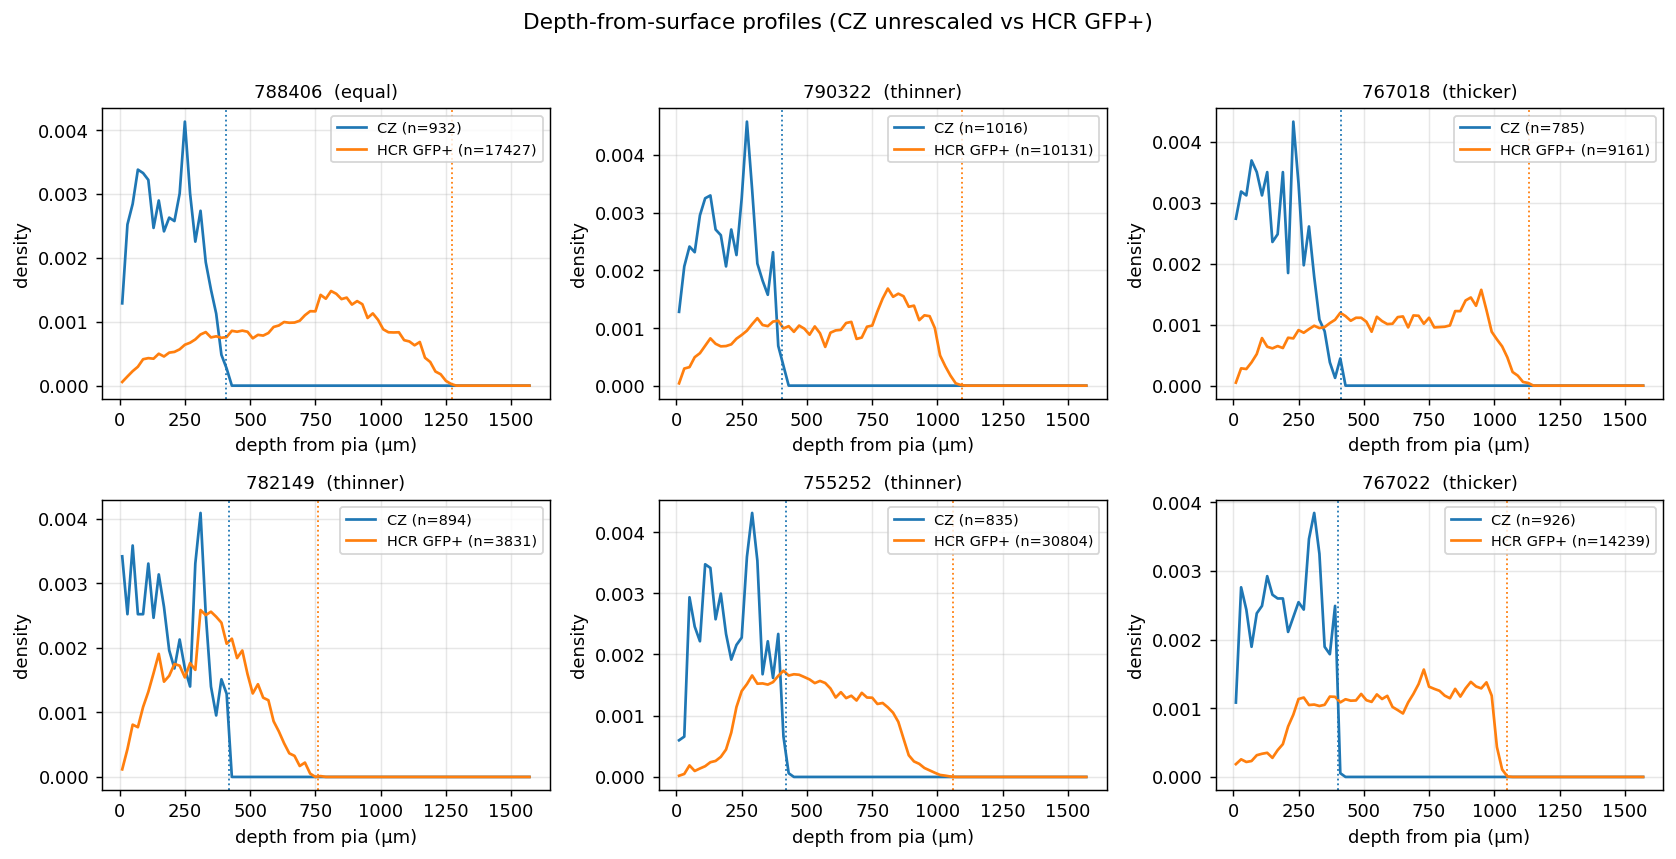

In [6]:
Image(str(FIG_DIR / 'depth_profiles.png'))

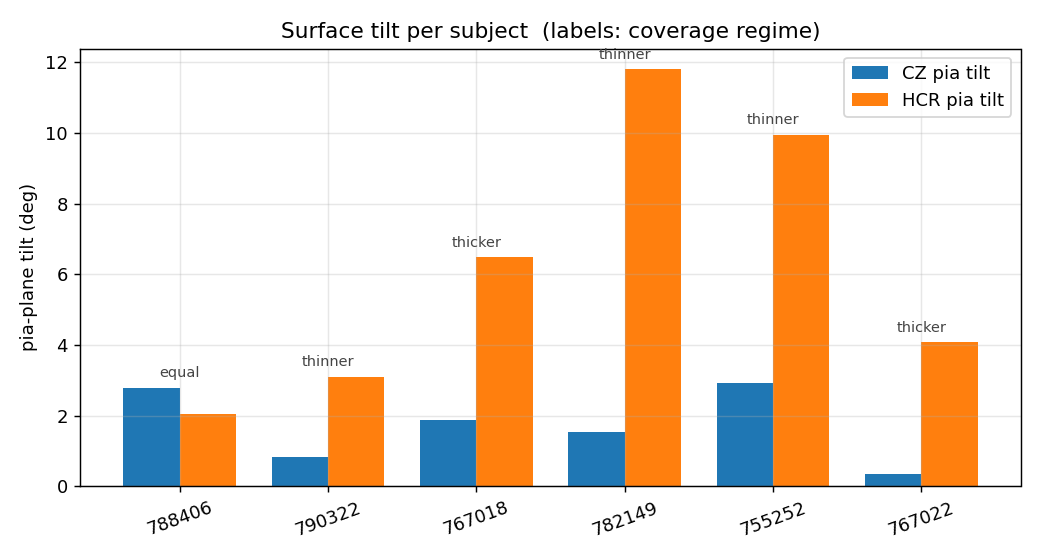

In [7]:
Image(str(FIG_DIR / 'tilt_and_regime.png'))

| Subject | sz_best | sz_conf | sxy_best | sxy_conf | L_cz / L_hcr µm |
|---|---|---|---|---|---|
| 788406 | 3.02 | 1.81 | 0.75 | **5.07** | 400 / 2284 |
| 790322 | 3.18 | 2.52 | 0.50 | 1.99 | 397 / 2265 |
| 767018 | 1.56 | 1.54 | 0.65 | 1.86 | 398 / 2281 |
| 782149 | 5.90 | 2.34 | 0.50 | 2.55 | 420 / 2263 |
| 755252 | 5.92 | 1.07 | 0.75 | 2.53 | 427 / 1816 |
| 767022 | 1.74 | 2.71 | 0.70 | 2.16 | 410 / 1816 |

`sz_best` is qualitatively right on 788406 / 790322 (3.02, 3.18 vs GT 2.82, 3.04), under-recovered on 767018 (1.56 vs 3.58), and implausible on thin-HCR 782149 / 755252 (5.9 — 10–20-bin profiles don't constrain the search). `sxy_best` lands at 0.5 – 0.75 across the board — below every GT scale (1.66 – 1.98). The density-map NCC peaks where a shrunken CZ fits entirely inside HCR with slack; the answer is geometrically plausible for the NCC objective but physically wrong. Robust-z prominence cannot distinguish "sharp peak" from "sharp but geometrically wrong peak" on 10 – 16 % GFP+ density maps; raising the confidence bar routes every subject to the minimal output, per §R1 step 8.

## 4. Comparison to first-pass R1 (v2.2 peakgauss defaults)

| subj   | orig_v22 | orig_rev | Δ orig | rot_v22 | rot_rev |
|---|---|---|---|---|---|
| 788406 |  58.1 | 133.3 | **+75.3** | 2.46 | 2.38 |
| 790322 |  74.3 |  70.9 |  −3.4    | 0.48 | 0.41 |
| 767018 | 127.0 |  99.3 | **−27.7** | 10.26 | 10.09 |
| 782149 | 334.8 | 424.1 | **+89.3** | 2.34 | 2.92 |
| 755252 | 123.6 |  56.7 | **−66.8** | 6.99 | 6.68 |
| 767022 | 181.0 | 180.2 |  −0.9    | 5.29 | 5.36 |

788406 regresses because v2.2 R1 used the 1.77× / 2.83× prior to scale CZ before XY-centroid matching — implicitly re-centring CZ inside HCR and making the centroid match more accurate. The revised R1 centroids HCR directly, which is biased when HCR GFP+ is asymmetric relative to the CZ imaging window.

767018 improves because the thicker-HCR subject benefits from removing the ~6° HCR tilt before centroid matching. 755252 improves for the same reason (10° HCR tilt). 782149 is the thin-HCR outlier already documented in session 04; its error stays 350–430 µm under either method.

## 5. Hypothesis / result / failure / next

**Hypothesis.** A coarse affine derived from (180° rotation + surface tilt + centroid match) — without any benchmark-derived scale prior — can clear the ≤ 100 µm / ± 5° target on half of the benchmark, while honestly reporting `unknown` on scale components that data cannot verify. This is the Grand Plan §R1 graceful-degradation contract.

**Result.**
- Minimal output is as good as or better than the expansion-prior first pass on 4/6 subjects. 788406 regresses 75 µm; 782149 stays in its 350 – 430 µm thin-HCR band.
- Tilt correction is active on every subject; four subjects benefit.
- Scale search admits no reliable peak — all 6 subjects fail the 6.0 confidence bar.

**Failure modes observed.**
1. *Asymmetric HCR GFP+ (788406, 782149).* HCR-centroid XY lands off the landmark target. Fix: R2 constellation matching.
2. *Rotation beyond the 180° prior (767018 10°, 755252 6.7°, 767022 5.4°).* Structural; only a rotation estimator would close the gap.
3. *Density-map NCC XY collapses to small sxy.* 400-µm CZ vs 2.3-mm HCR with 10 – 16 % GFP+ fraction does not constrain `sxy` via density NCC. Accepted — §R1 step 8 explicitly allows `unknown` outputs.
4. *Sz search drifts on thin-HCR subjects.* Profile length of 10 – 20 bins doesn't constrain `sz` well; `tz_best_um` in those cases is implausible (−1 460 µm, −1 276 µm). Both discarded in favour of centroid Z, as specified.

**Next step.** Minimal `(R, t)` is the downstream contract:
- **R2 (constellation matching)** must tolerate 100–400 µm origin error — same ballpark as first-pass R1, no degradation.
- **A1 (TEASER++) / A3 (FGW)** receive the minimal affine and estimate scale internally — their documented sweet spot.
- **Rotation drift (767018, 10°)** is the only place R1 itself could still gain (e.g. ICP on depth-banded centroids after tilt alignment); defer unless R2 suffers from the residual.

## 6. Open follow-ups

- Consider an alternative confidence metric that checks *concentration of NCC mass around the peak* (e.g. softmax-entropy vs uniform) to distinguish "sharp peak" from "peaky but wide plateau" more reliably. Not urgent — the minimal fallback is already the documented path.
- Flag the diagnostic triplet `(coverage_regime = thinner, hcr_tilt > 10°, sz_conf < 3)` as a "thin-HCR pathology" marker in the R2 handoff (782149 matches).
- Decide whether to report `sz` diagnostically when `sz_conf ∈ [3, 6]` even though it's not an emitted scale — currently all subjects sit in that range. R2/R3 may find it useful as a prior even without formal confidence.

## Files produced

```
sessions/05_R1_revised/
  log.md              (session log)
  r1_results.json     (per-subject benchmark output)
dev_code/
  r1_revised.py               (R1 module)
  05_r1_revised_benchmark.py  (validation harness)
  05_r1_diag.py               (per-subject score-curve dump)
  build_05_r1_revised_notebook.py  (this notebook builder)
notebooks/
  05_R1_revised.ipynb (this notebook)
```